Rows after merging Q2 clusters: 41872

Imported Q2 cluster counts:
cluster
1    16172
2    24028
3     1672
Name: count, dtype: int64

Train size: (29310, 11)
Validation size: (4145, 11)
Test size: (8417, 11)

Cluster default rates from imported Q2 clusters:
cluster
1    0.196659
2    0.151436
3    0.189019
Name: default_flag, dtype: float64

Overall training default rate (fallback): 0.1703

CLUSTER BASELINE THRESHOLD
Manual threshold for Cluster Baseline: 0.17

Validation-set metrics at manual cluster threshold:
Accuracy:  0.5489
Precision: 0.1854
Recall:    0.4858
F1-score:  0.2684
ROC-AUC:   0.5266

CLUSTER-BASED BASELINE PERFORMANCE (TEST SET)
Threshold: 0.17
Accuracy: 0.5702
Precision: 0.1939
Recall: 0.4829
F1-score: 0.2767
ROC-AUC: 0.5353

Confusion Matrix:
[[4107 2877]
 [ 741  692]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.59      0.69      6984
           1       0.19      0.48      0.28      1433

    accurac

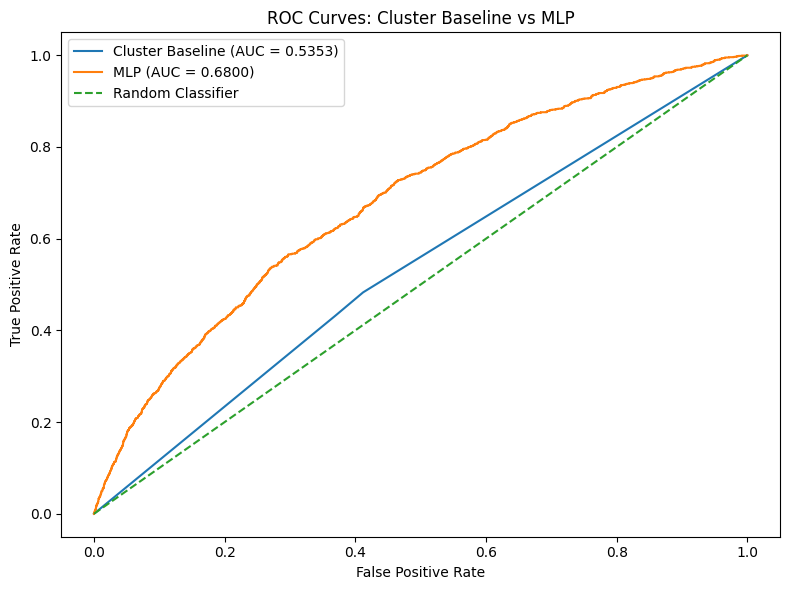

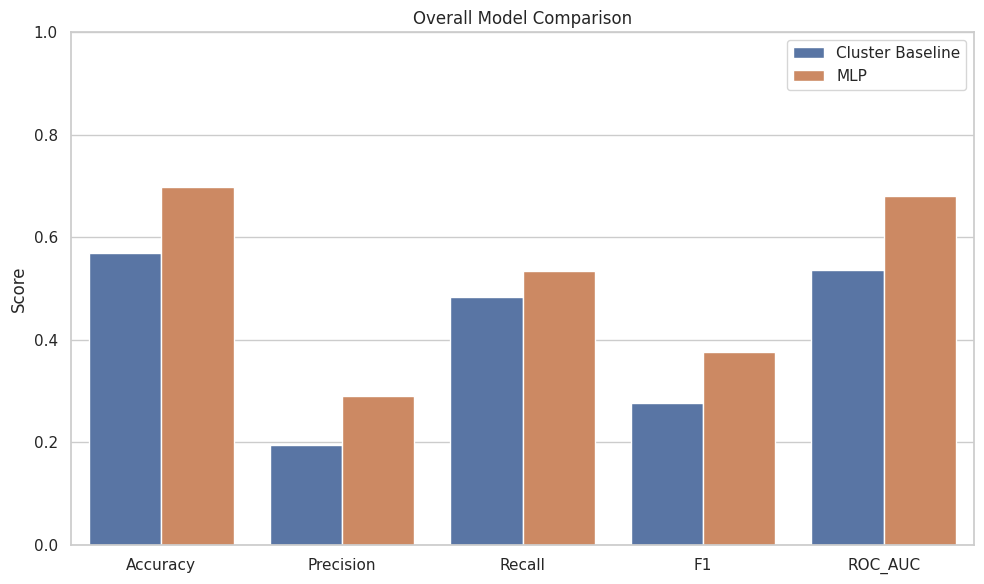

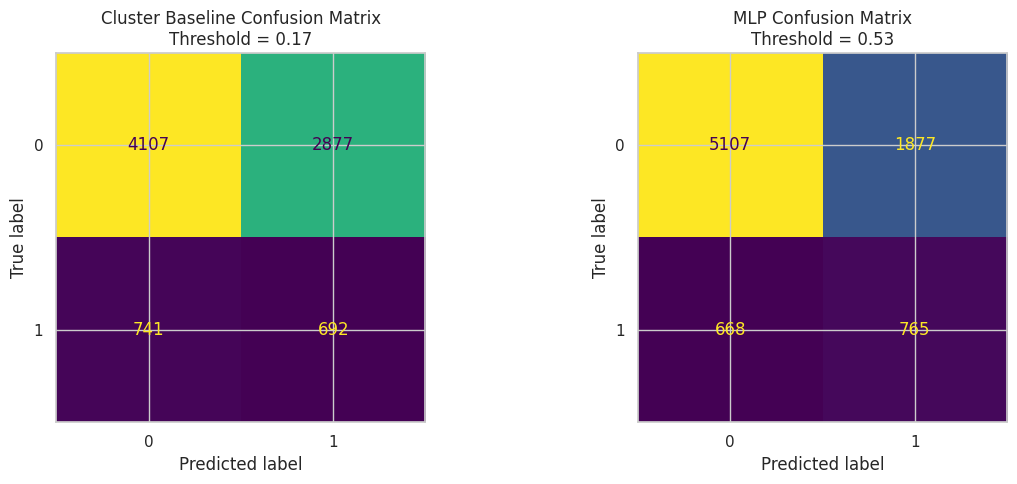

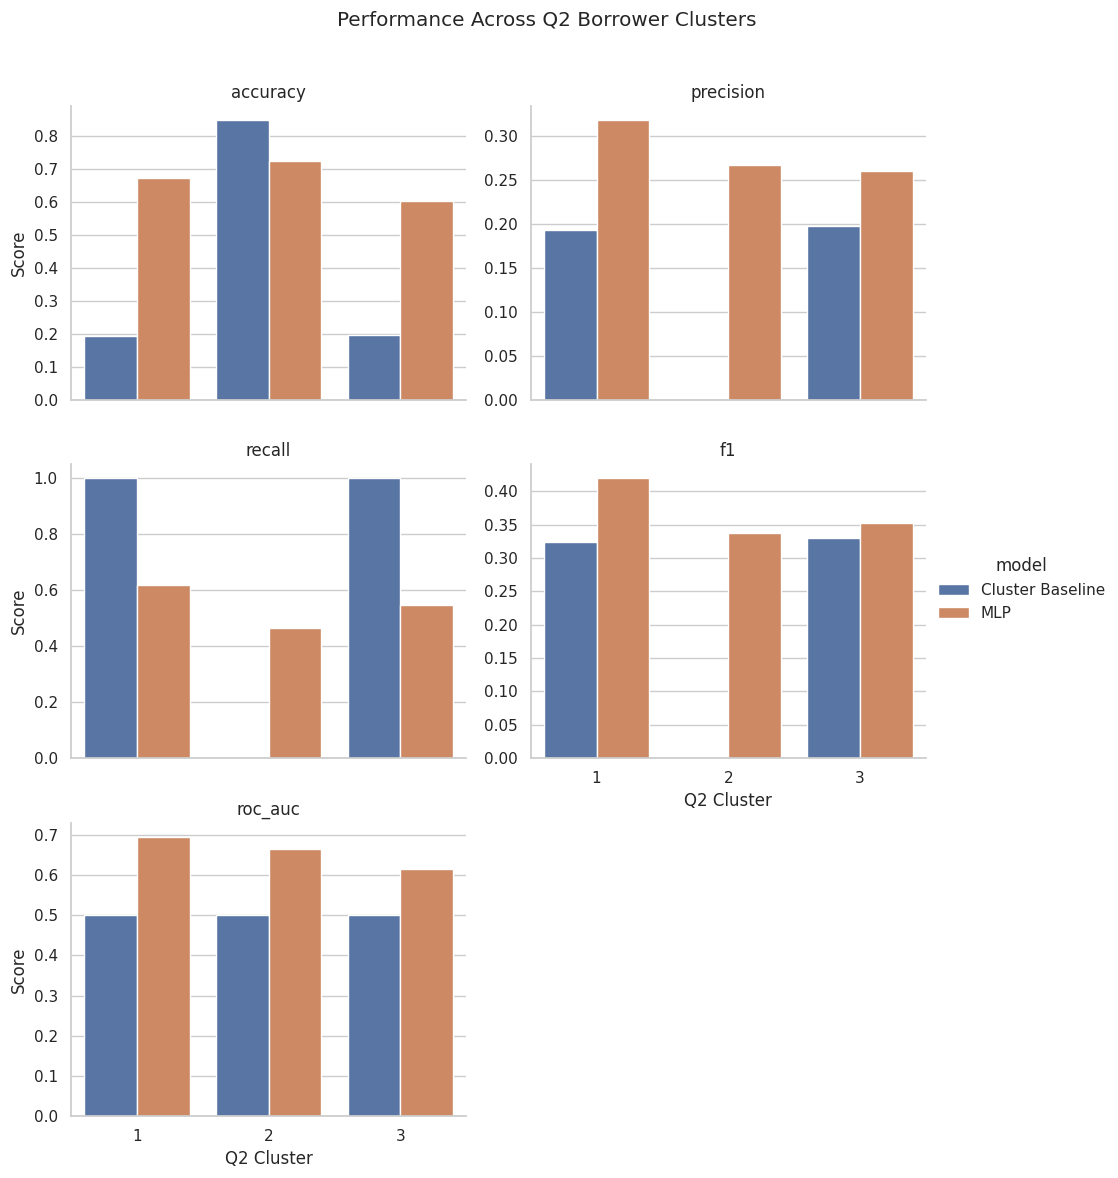

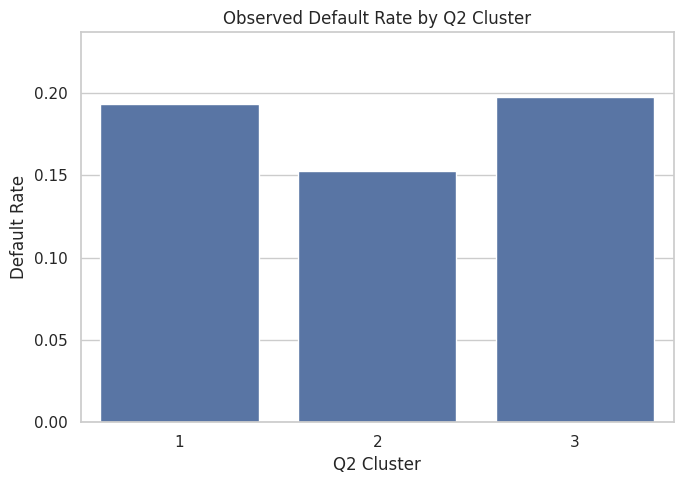

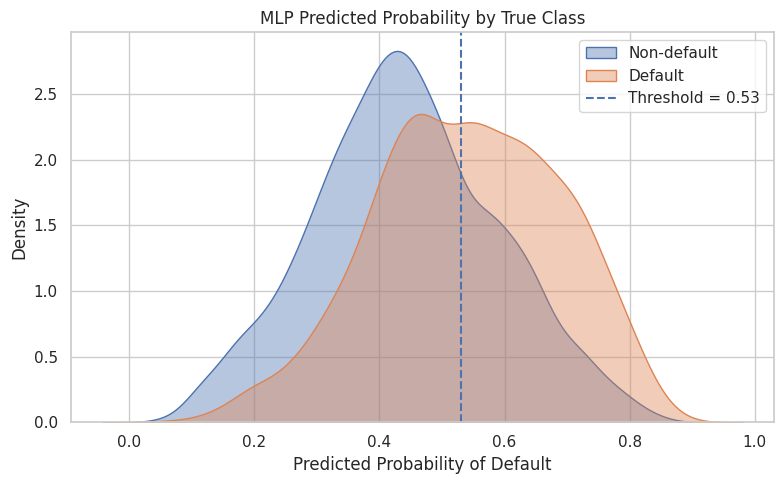

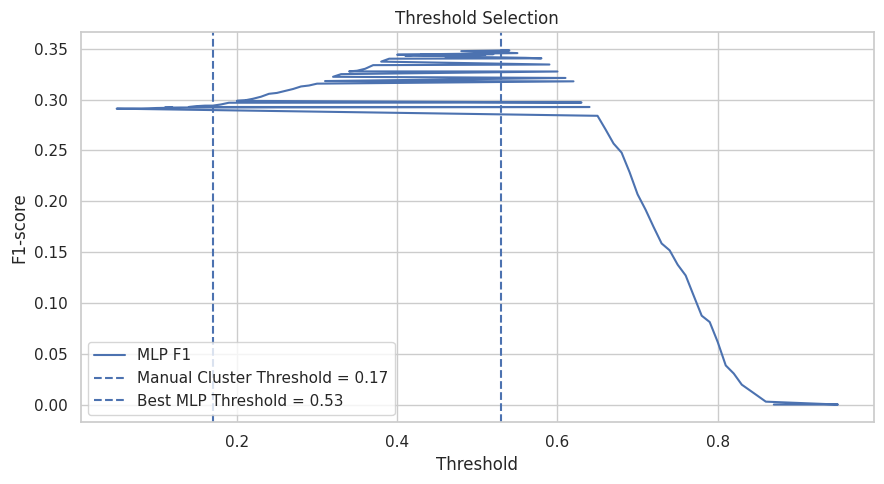

In [3]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    f1_score,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping


# 0. REPRODUCIBILITY
SEED = 123

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)



# 1. LOAD MAIN DATA

df = pd.read_csv(
    "early_2012_2013_loan_sample_with_outcome.csv",
    engine="python",
    on_bad_lines="skip"
)

# Keep only completed loans
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()

# Target variable
df["default_flag"] = np.where(df["loan_status"] == "Charged Off", 1, 0)

# Convert percentage columns
df["revol_util"] = pd.to_numeric(
    df["revol_util"].astype(str).str.replace("%", "", regex=False),
    errors="coerce"
)
df["int_rate"] = pd.to_numeric(
    df["int_rate"].astype(str).str.replace("%", "", regex=False),
    errors="coerce"
)

features = [
    "funded_amnt",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "int_rate"
]

required_cols = ["id", "default_flag"] + features
df = df[required_cols].copy()

# Ensure numeric
for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill missing values in predictors
df[features] = df[features].fillna(df[features].mean())

# Drop missing IDs if any
df = df.dropna(subset=["id"]).copy()


# 2. IMPORT Q2 CLUSTERS

q2_clusters = pd.read_csv("q2_final_cluster_assignments_with_labels.csv")
q2_clusters = q2_clusters[["id", "cluster"]].copy()

# Merge Q2 clusters into Q3 data
df = df.merge(q2_clusters, on="id", how="inner")

print("Rows after merging Q2 clusters:", len(df))
print("\nImported Q2 cluster counts:")
print(df["cluster"].value_counts().sort_index())


# 3. TRAIN / VALIDATION / TEST SPLIT

X = df[features].copy()
y = df["default_flag"].copy()
clusters = df["cluster"].copy()
ids = df["id"].copy()

X_train, X_temp, y_train, y_temp, cluster_train, cluster_temp, id_train, id_temp = train_test_split(
    X, y, clusters, ids,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test, cluster_val, cluster_test, id_val, id_test = train_test_split(
    X_temp, y_temp, cluster_temp, id_temp,
    test_size=0.67,
    random_state=SEED,
    stratify=y_temp
)

print("\nTrain size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)



# 4. STANDARDISE FEATURES

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



# 5. HELPER FUNCTIONS

def safe_roc_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


def evaluate_predictions(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": safe_roc_auc(y_true, y_prob),
        "y_pred": y_pred
    }


def find_best_threshold(y_true, y_prob, metric="f1", threshold_grid=None):
    if threshold_grid is None:
        threshold_grid = np.arange(0.05, 0.96, 0.01)

    rows = []
    for t in threshold_grid:
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold": round(float(t), 4),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        })

    results = pd.DataFrame(rows)
    results = results.sort_values([metric, "threshold"], ascending=[False, False]).reset_index(drop=True)
    best_threshold = results.loc[0, "threshold"]

    return best_threshold, results


def compute_metrics(group, prob_col, pred_col):
    return pd.Series({
        "n": len(group),
        "accuracy": accuracy_score(group["actual_default"], group[pred_col]),
        "precision": precision_score(group["actual_default"], group[pred_col], zero_division=0),
        "recall": recall_score(group["actual_default"], group[pred_col], zero_division=0),
        "f1": f1_score(group["actual_default"], group[pred_col], zero_division=0),
        "roc_auc": safe_roc_auc(group["actual_default"], group[prob_col])
    })


# 6. CLUSTER-BASED BASELINE USING IMPORTED Q2 CLUSTERS

cluster_default_rate = (
    pd.DataFrame({
        "cluster": cluster_train.values,
        "default_flag": y_train.values
    })
    .groupby("cluster")["default_flag"]
    .mean()
)

overall_train_default_rate = y_train.mean()

print("\nCluster default rates from imported Q2 clusters:")
print(cluster_default_rate)
print("\nOverall training default rate (fallback):", round(overall_train_default_rate, 4))

cluster_prob_val = pd.Series(cluster_val.values).map(cluster_default_rate).fillna(overall_train_default_rate).values
cluster_prob_test = pd.Series(cluster_test.values).map(cluster_default_rate).fillna(overall_train_default_rate).values


# 7.THRESHOLD FOR CLUSTER BASELINE

threshold_cluster = 0.17

print("\n" + "=" * 60)
print("CLUSTER BASELINE THRESHOLD")
print("=" * 60)
print("Manual threshold for Cluster Baseline:", threshold_cluster)

cluster_eval_val = evaluate_predictions(y_val, cluster_prob_val, threshold_cluster)
cluster_eval_test = evaluate_predictions(y_test, cluster_prob_test, threshold_cluster)
cluster_pred_test = cluster_eval_test["y_pred"]

cluster_accuracy = cluster_eval_test["accuracy"]
cluster_precision = cluster_eval_test["precision"]
cluster_recall = cluster_eval_test["recall"]
cluster_f1 = cluster_eval_test["f1"]
cluster_auc = cluster_eval_test["roc_auc"]

print("\nValidation-set metrics at manual cluster threshold:")
print(f"Accuracy:  {cluster_eval_val['accuracy']:.4f}")
print(f"Precision: {cluster_eval_val['precision']:.4f}")
print(f"Recall:    {cluster_eval_val['recall']:.4f}")
print(f"F1-score:  {cluster_eval_val['f1']:.4f}")
print(f"ROC-AUC:   {cluster_eval_val['roc_auc']:.4f}")

print("\n" + "=" * 60)
print("CLUSTER-BASED BASELINE PERFORMANCE (TEST SET)")
print("=" * 60)
print("Threshold:", round(threshold_cluster, 4))
print("Accuracy:", round(cluster_accuracy, 4))
print("Precision:", round(cluster_precision, 4))
print("Recall:", round(cluster_recall, 4))
print("F1-score:", round(cluster_f1, 4))
print("ROC-AUC:", round(cluster_auc, 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, cluster_pred_test))
print("\nClassification Report:")
print(classification_report(y_test, cluster_pred_test, zero_division=0))



# 8. MLP MODEL

smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE class distribution:")
print(pd.Series(y_train_smote).value_counts())

model = Sequential([
    Input(shape=(X_train_smote.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_smote,
    y_train_smote,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)



# 9. TUNE MLP THRESHOLD ON VALIDATION SET

mlp_prob_val = model.predict(X_val_scaled, verbose=0).ravel()
mlp_prob_test = model.predict(X_test_scaled, verbose=0).ravel()

best_threshold_mlp, mlp_threshold_results = find_best_threshold(
    y_true=y_val,
    y_prob=mlp_prob_val,
    metric="f1"
)

print("\n" + "=" * 60)
print("MLP THRESHOLD TUNING (VALIDATION SET)")
print("=" * 60)
print("Best threshold for MLP:", best_threshold_mlp)
print("\nTop threshold candidates:")
print(mlp_threshold_results.head(10).round(4))



# 10. EVALUATE MLP ON TEST SET

mlp_eval_test = evaluate_predictions(y_test, mlp_prob_test, best_threshold_mlp)
mlp_pred_test = mlp_eval_test["y_pred"]

mlp_accuracy = mlp_eval_test["accuracy"]
mlp_precision = mlp_eval_test["precision"]
mlp_recall = mlp_eval_test["recall"]
mlp_f1 = mlp_eval_test["f1"]
mlp_auc = mlp_eval_test["roc_auc"]

print("\n" + "=" * 60)
print("MLP PERFORMANCE (TEST SET)")
print("=" * 60)
print("Threshold:", round(best_threshold_mlp, 4))
print("Accuracy:", round(mlp_accuracy, 4))
print("Precision:", round(mlp_precision, 4))
print("Recall:", round(mlp_recall, 4))
print("F1-score:", round(mlp_f1, 4))
print("ROC-AUC:", round(mlp_auc, 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, mlp_pred_test))
print("\nClassification Report:")
print(classification_report(y_test, mlp_pred_test, zero_division=0))



# 11. OVERALL MODEL COMPARISON

comparison = pd.DataFrame({
    "Model": ["Cluster Baseline", "MLP"],
    "Chosen_Threshold": [threshold_cluster, best_threshold_mlp],
    "Accuracy": [cluster_accuracy, mlp_accuracy],
    "Precision": [cluster_precision, mlp_precision],
    "Recall": [cluster_recall, mlp_recall],
    "F1": [cluster_f1, mlp_f1],
    "ROC_AUC": [cluster_auc, mlp_auc]
})

print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON (TEST SET)")
print("=" * 60)
print(comparison.round(4))



# 12. COMPARE PERFORMANCE ACROSS Q2 BORROWER CLUSTERS

test_results = pd.DataFrame({
    "id": id_test.values,
    "cluster": cluster_test.values,
    "actual_default": y_test.values,
    "cluster_baseline_prob": cluster_prob_test,
    "cluster_baseline_pred": cluster_pred_test,
    "mlp_prob": mlp_prob_test,
    "mlp_pred": mlp_pred_test
})

cluster_baseline_by_cluster = (
    test_results.groupby("cluster")[["actual_default", "cluster_baseline_prob", "cluster_baseline_pred"]]
    .apply(lambda d: compute_metrics(d, "cluster_baseline_prob", "cluster_baseline_pred"))
    .reset_index()
)
cluster_baseline_by_cluster["model"] = "Cluster Baseline"

mlp_by_cluster = (
    test_results.groupby("cluster")[["actual_default", "mlp_prob", "mlp_pred"]]
    .apply(lambda d: compute_metrics(d, "mlp_prob", "mlp_pred"))
    .reset_index()
)
mlp_by_cluster["model"] = "MLP"

clusterwise_comparison = pd.concat(
    [cluster_baseline_by_cluster, mlp_by_cluster],
    ignore_index=True
)

clusterwise_comparison = clusterwise_comparison[
    ["model", "cluster", "n", "accuracy", "precision", "recall", "f1", "roc_auc"]
]

print("\n" + "=" * 60)
print("PERFORMANCE ACROSS Q2 BORROWER CLUSTERS")
print("=" * 60)
print(clusterwise_comparison.round(4))



# 13. ROC CURVES

cluster_fpr, cluster_tpr, _ = roc_curve(y_test, cluster_prob_test)
mlp_fpr, mlp_tpr, _ = roc_curve(y_test, mlp_prob_test)

plt.figure(figsize=(8, 6))
plt.plot(cluster_fpr, cluster_tpr, label=f"Cluster Baseline (AUC = {cluster_auc:.4f})")
plt.plot(mlp_fpr, mlp_tpr, label=f"MLP (AUC = {mlp_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Cluster Baseline vs MLP")
plt.legend()
plt.tight_layout()
plt.show()



# 14. VISUALISATIONS

sns.set_theme(style="whitegrid")

# A. Overall model comparison
comparison_long = comparison.melt(
    id_vars=["Model", "Chosen_Threshold"],
    value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)
plt.title("Overall Model Comparison")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("")
plt.legend(title="")
plt.tight_layout()
plt.show()

# B. Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    cluster_pred_test,
    ax=axes[0],
    colorbar=False
)
axes[0].set_title(f"Cluster Baseline Confusion Matrix\nThreshold = {threshold_cluster:.2f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    mlp_pred_test,
    ax=axes[1],
    colorbar=False
)
axes[1].set_title(f"MLP Confusion Matrix\nThreshold = {best_threshold_mlp:.2f}")

plt.tight_layout()
plt.show()

# C. Cluster-wise comparison
clusterwise_long = clusterwise_comparison.melt(
    id_vars=["model", "cluster", "n"],
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score"
)

g = sns.catplot(
    data=clusterwise_long,
    x="cluster",
    y="score",
    hue="model",
    col="metric",
    kind="bar",
    col_wrap=2,
    height=4,
    aspect=1.2,
    sharey=False
)
g.set_axis_labels("Q2 Cluster", "Score")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Performance Across Q2 Borrower Clusters")
plt.show()

# D. Observed default rate by cluster
default_rate_by_cluster = (
    test_results.groupby("cluster")["actual_default"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=default_rate_by_cluster,
    x="cluster",
    y="actual_default"
)
plt.title("Observed Default Rate by Q2 Cluster")
plt.xlabel("Q2 Cluster")
plt.ylabel("Default Rate")
plt.ylim(0, max(default_rate_by_cluster["actual_default"]) * 1.2 if len(default_rate_by_cluster) > 0 else 1)
plt.tight_layout()
plt.show()

# E. Predicted probability distribution for MLP
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=test_results[test_results["actual_default"] == 0],
    x="mlp_prob",
    label="Non-default",
    fill=True,
    common_norm=False,
    alpha=0.4
)
sns.kdeplot(
    data=test_results[test_results["actual_default"] == 1],
    x="mlp_prob",
    label="Default",
    fill=True,
    common_norm=False,
    alpha=0.4
)
plt.axvline(best_threshold_mlp, linestyle="--", label=f"Threshold = {best_threshold_mlp:.2f}")
plt.title("MLP Predicted Probability by True Class")
plt.xlabel("Predicted Probability of Default")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# F. MLP threshold tuning curve only
plt.figure(figsize=(9, 5))
plt.plot(mlp_threshold_results["threshold"], mlp_threshold_results["f1"], label="MLP F1")
plt.axvline(threshold_cluster, linestyle="--", label=f"Manual Cluster Threshold = {threshold_cluster:.2f}")
plt.axvline(best_threshold_mlp, linestyle="--", label=f"Best MLP Threshold = {best_threshold_mlp:.2f}")
plt.title("Threshold Selection")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)
plt.title("Overall Model Comparison")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("")
plt.legend(title="")
plt.tight_layout()
plt.savefig("q3_overall_model_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

g = sns.catplot(
    data=clusterwise_long,
    x="cluster",
    y="score",
    hue="model",
    col="metric",
    kind="bar",
    col_wrap=2,
    height=4,
    aspect=1.2,
    sharey=False
)
g.set_axis_labels("Q2 Cluster", "Score")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Performance Across Q2 Borrower Clusters")
g.savefig("q3_clusterwise_performance.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(8, 6))
plt.plot(cluster_fpr, cluster_tpr, label=f"Cluster Baseline (AUC = {cluster_auc:.4f})")
plt.plot(mlp_fpr, mlp_tpr, label=f"MLP (AUC = {mlp_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Cluster Baseline vs MLP")
plt.legend()
plt.tight_layout()
plt.savefig("q3_roc_curves.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(9, 5))
plt.plot(mlp_threshold_results["threshold"], mlp_threshold_results["f1"], label="MLP F1")
plt.axvline(threshold_cluster, linestyle="--", label=f"Manual Cluster Threshold = {threshold_cluster:.2f}")
plt.axvline(best_threshold_mlp, linestyle="--", label=f"Best MLP Threshold = {best_threshold_mlp:.2f}")
plt.title("Threshold Selection")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.legend()
plt.tight_layout()
plt.savefig("q3_threshold_tuning.png", dpi=300, bbox_inches="tight")
plt.close()

